# 06. Mô hình hồi quy nâng cao (Advanced Regression Models)

Notebook này sẽ triển khai và đánh giá các mô hình hồi quy nâng cao đặc biệt:
* **Hồi quy Ridge với Tối ưu hóa Siêu tham số (Ridge Regression with Hyperparameter Optimization)**
* **Hồi quy Kernel Ridge (Kernel Ridge Regression)**
* **Hồi quy Bayesian và Tối đa hóa Bằng chứng (Bayesian Regression & Evidence Maximization)**
* **Quá trình Gaussian cho Hồi quy (Gaussian Processes for Regression)**
* **Hồi quy Robust (Robust Regression)**

## 0. Import thư viện, load dữ liệu và helper dùng chung

Toàn bộ notebook chỉ dùng `numpy`, `pandas`, `matplotlib` cho phần cài đặt và trực quan hóa. Dữ liệu được nạp từ pipeline tiền xử lý có sẵn, trong đó target đang ở không gian `log(cnt + 1)` để giảm độ lệch và giữ tính ổn định số học.

Ta ký hiệu:

$$
\mathcal{D} = \{(\mathbf{x}_i, t_i)\}_{i=1}^N, \quad \mathbf{x}_i \in \mathbb{R}^D
$$

và sử dụng các chỉ số:

$$
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(t_i - \hat{t}_i)^2,
\quad
\text{RMSE} = \sqrt{\text{MSE}},
\quad
R^2 = 1 - \frac{\sum_i (t_i - \hat{t}_i)^2}{\sum_i (t_i - \bar{t})^2}.
$$

**Ý tưởng triển khai**:
- Dùng helper chung cho metric, chia k-fold, lấy mẫu con và trực quan hóa.
- Các mô hình có độ phức tạp nhân ma trận kernel sẽ dùng tập con đại diện vì chi phí bộ nhớ là $O(N^2)$ và chi phí giải hệ là $O(N^3)$.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
np.set_printoptions(suppress=True, precision=4)


def resolve_part1_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "code" / "Part1_Regression",
        Path.cwd().parent,
    ]
    for candidate in candidates:
        if (candidate / "data" / "load_data.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate code/Part1_Regression for data loading.")


PART1_ROOT = resolve_part1_root()
if str(PART1_ROOT) not in sys.path:
    sys.path.insert(0, str(PART1_ROOT))

from data.load_data import load_regression_data

data = load_regression_data()
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]
feature_names = data["feature_names"]

X_dev = np.vstack([X_train, X_val])
y_dev = np.concatenate([y_train, y_val])

temp_idx = feature_names.index("temp")

advanced_results = {}


def add_bias(X: np.ndarray) -> np.ndarray:
    return np.column_stack([np.ones(X.shape[0]), X])


def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mse(y_true, y_pred)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def r2_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0


def compute_all_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "MSE": mse(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def print_metrics(metrics: dict, model_name: str) -> None:
    print(f"\n{'=' * 60}")
    print(model_name)
    print(f"{'=' * 60}")
    for key, value in metrics.items():
        print(f"{key:>8s}: {value:.6f}")
    print(f"{'=' * 60}")


def k_fold_split(n_samples: int, k: int = 5, seed: int = SEED):
    rng = np.random.default_rng(seed)
    indices = np.arange(n_samples)
    rng.shuffle(indices)
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[: n_samples % k] += 1
    folds = []
    current = 0
    for size in fold_sizes:
        val_idx = indices[current: current + size]
        train_idx = np.concatenate([indices[:current], indices[current + size:]])
        folds.append((train_idx, val_idx))
        current += size
    return folds


def sample_subset(X: np.ndarray, y: np.ndarray, size: int, seed: int):
    if size >= len(X):
        return X.copy(), y.copy()
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(X), size=size, replace=False)
    return X[indices], y[indices]


def median_pairwise_distance(X: np.ndarray, max_points: int = 200, seed: int = SEED) -> float:
    X_probe, _ = sample_subset(X, np.zeros(len(X)), min(max_points, len(X)), seed)
    sq_dist = (
        np.sum(X_probe ** 2, axis=1, keepdims=True)
        + np.sum(X_probe ** 2, axis=1, keepdims=True).T
        - 2.0 * X_probe @ X_probe.T
    )
    sq_dist = sq_dist[np.triu_indices_from(sq_dist, k=1)]
    sq_dist = sq_dist[sq_dist > 1e-12]
    if sq_dist.size == 0:
        return 1.0
    return float(np.sqrt(np.median(sq_dist)))


class OrdinaryLeastSquares:
    def __init__(self):
        self.w = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        X_b = add_bias(X)
        reg = 1e-8 * np.eye(X_b.shape[1])
        self.w = np.linalg.solve(X_b.T @ X_b + reg, X_b.T @ y)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return add_bias(X) @ self.w


class RidgeRegression:
    def __init__(self, lam: float = 1.0):
        self.lam = lam
        self.w = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        X_b = add_bias(X)
        reg = self.lam * np.eye(X_b.shape[1])
        reg[0, 0] = 0.0
        self.w = np.linalg.solve(X_b.T @ X_b + reg, X_b.T @ y)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return add_bias(X) @ self.w


def select_ridge_lambda_cv(
    X: np.ndarray,
    y: np.ndarray,
    lambda_grid: np.ndarray,
    k: int = 5,
    seed: int = SEED,
) -> dict:
    folds = k_fold_split(len(X), k=k, seed=seed)
    mean_scores = []
    std_scores = []
    for lam in lambda_grid:
        fold_scores = []
        for train_idx, val_idx in folds:
            model = RidgeRegression(lam=lam).fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            fold_scores.append(mse(y[val_idx], preds))
        mean_scores.append(float(np.mean(fold_scores)))
        std_scores.append(float(np.std(fold_scores)))
    best_idx = int(np.argmin(mean_scores))
    return {
        "best_lambda": float(lambda_grid[best_idx]),
        "best_score": mean_scores[best_idx],
        "mean_scores": mean_scores,
        "std_scores": std_scores,
    }


def plot_interval_band(ax, x_values, y_mean, y_std, y_true, title, x_label):
    ax.plot(x_values, y_true, "o", ms=3, alpha=0.45, label="Actual")
    ax.plot(x_values, y_mean, color="tab:red", lw=2, label="Predictive mean")
    ax.fill_between(
        x_values,
        y_mean - 2.0 * y_std,
        y_mean + 2.0 * y_std,
        color="tab:orange",
        alpha=0.25,
        label="Mean +/- 2 sigma",
    )
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("log(cnt + 1)")
    ax.legend()


print(f"X_train / y_train : {X_train.shape} / {y_train.shape}")
print(f"X_val   / y_val   : {X_val.shape} / {y_val.shape}")
print(f"X_test  / y_test  : {X_test.shape} / {y_test.shape}")
print(f"Number of features: {len(feature_names)}")
print("The target is already log-transformed by the preprocessing pipeline.")
print(f"Example features  : {feature_names[:10]}")


X_train / y_train : (12165, 49) / (12165,)
X_val   / y_val   : (1737, 49) / (1737,)
X_test  / y_test  : (3477, 49) / (3477,)
Number of features: 49
The target is already log-transformed by the preprocessing pipeline.
Example features  : ['temp', 'hum', 'windspeed', 'season_2', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6']


Dữ liệu regression đã được chia thành `train / val / test` và có 49 đặc trưng sau one-hot encoding và feature engineering. Điều này rất quan trọng cho phần nâng cao:

- Bayesian và robust regression có thể học trên toàn bộ tập `train + val`.
- Kernel Ridge và Gaussian Process phải dùng tập con đại diện, nếu không ma trận kernel sẽ quá lớn cho notebook.
- Tất cả metric được báo cáo trên cùng không gian target `log(cnt + 1)` để nhất quán với các notebook 03, 04, 05.

## 1. Bayesian Linear Regression

Trong Bayesian Linear Regression, vector trọng số không còn là một giá trị điểm mà là một biến ngẫu nhiên:

$$
p(\mathbf{w}) = \mathcal{N}(\mathbf{w} \mid \mathbf{0}, \alpha^{-1}\mathbf{I}),
\qquad
p(\mathbf{t} \mid \mathbf{X}, \mathbf{w}, \beta) = \mathcal{N}(\mathbf{t} \mid \mathbf{X}\mathbf{w}, \beta^{-1}\mathbf{I}).
$$

Khi kết hợp prior Gaussian và likelihood Gaussian, hậu nghiệm vẫn có dạng Gaussian:

$$
p(\mathbf{w} \mid \mathbf{t}) = \mathcal{N}(\mathbf{w} \mid \mathbf{m}_N, \mathbf{S}_N)
$$

với

$$
\mathbf{S}_N = \left(\alpha \mathbf{I} + \beta \mathbf{X}^\top \mathbf{X}\right)^{-1},
\qquad
\mathbf{m}_N = \beta \mathbf{S}_N \mathbf{X}^\top \mathbf{t}.
$$

Phần dự đoán cho điểm mới $\mathbf{x}_*$ có cả trung bình lẫn độ bất định:

$$
p(t_* \mid \mathbf{x}_*, \mathcal{D}) =
\mathcal{N}\left(
    t_* \mid \mathbf{m}_N^\top \mathbf{x}_*,
    \beta^{-1} + \mathbf{x}_*^\top \mathbf{S}_N \mathbf{x}_*
\right).
$$

**Ý tưởng cài đặt**:
- Dùng nghiệm đóng để tính trực tiếp $\mathbf{m}_N$ và $\mathbf{S}_N$.
- Chọn `alpha` và `beta` khởi tạo từ residual của OLS để có baseline hợp lý.
- Vẽ `mean +/- 2 sigma` trên một tập con test đã sắp xếp theo feature `temp` để thấy rõ uncertainty.


Bayesian Linear Regression on the full test split
     MSE: 0.348523
    RMSE: 0.590358
     MAE: 0.445962
      R2: 0.825527
Initial beta estimated from OLS residual variance: 2.729313


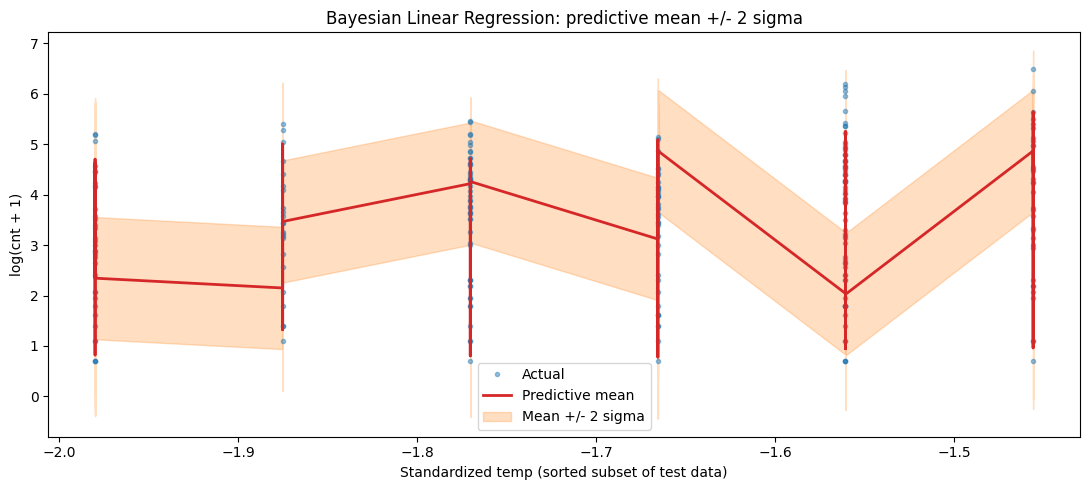

In [2]:
class BayesianLinearRegression:
    def __init__(self, alpha: float = 1.0, beta: float = 1.0):
        self.alpha = alpha
        self.beta = beta
        self.posterior_mean = None
        self.posterior_cov = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        X_b = add_bias(X)
        n_features = X_b.shape[1]
        precision = self.alpha * np.eye(n_features) + self.beta * (X_b.T @ X_b)
        self.posterior_cov = np.linalg.inv(precision)
        self.posterior_mean = self.beta * self.posterior_cov @ X_b.T @ y
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_b = add_bias(X)
        return X_b @ self.posterior_mean

    def predict_distribution(self, X: np.ndarray):
        X_b = add_bias(X)
        mean = X_b @ self.posterior_mean
        variance = 1.0 / self.beta + np.sum((X_b @ self.posterior_cov) * X_b, axis=1)
        variance = np.maximum(variance, 1e-12)
        return mean, np.sqrt(variance)


ols_for_noise = OrdinaryLeastSquares().fit(X_train, y_train)
residual_var = np.var(y_train - ols_for_noise.predict(X_train))
initial_beta = 1.0 / max(residual_var, 1e-6)

bayes_lr = BayesianLinearRegression(alpha=1.0, beta=initial_beta).fit(X_dev, y_dev)
bayes_pred, bayes_std = bayes_lr.predict_distribution(X_test)
bayes_metrics = compute_all_metrics(y_test, bayes_pred)
print_metrics(bayes_metrics, "Bayesian Linear Regression on the full test split")
print(f"Initial beta estimated from OLS residual variance: {initial_beta:.6f}")

advanced_results["Bayesian Linear Regression"] = {
    "Setting": "full test",
    **bayes_metrics,
}

plot_size = min(250, len(X_test))
plot_order = np.argsort(X_test[:, temp_idx])[:plot_size]
x_plot = X_test[plot_order, temp_idx]
mean_plot = bayes_pred[plot_order]
std_plot = bayes_std[plot_order]
y_plot = y_test[plot_order]

fig, ax = plt.subplots(figsize=(11, 5))
plot_interval_band(
    ax=ax,
    x_values=x_plot,
    y_mean=mean_plot,
    y_std=std_plot,
    y_true=y_plot,
    title="Bayesian Linear Regression: predictive mean +/- 2 sigma",
    x_label="Standardized temp (sorted subset of test data)",
)
plt.tight_layout()
plt.show()


- Dải uncertainty hẹp hơn ở những vùng có nhiều dữ liệu huấn luyện.
- Dải uncertainty rộng hơn ở các mẫu có cấu hình đặc trưng ít xuất hiện.
- Về bản chất, mô hình này gần với Ridge/MAP, nhưng giàu hơn OLS vì nó giữ được phân bố hậu nghiệm của trọng số.

Trong các section sau, Evidence Maximization sẽ tìm `alpha` và `beta` một cách hệ thống hơn thay vì đặt tay như baseline này.

## 2. Evidence Maximization (Empirical Bayes)

Thay vì chọn tay độ mạnh prior $\alpha$ và độ chính xác noise $\beta$, ta tối ưu chúng thông qua hàm chứng cứ (evidence):

$$
p(\mathbf{t} \mid \alpha, \beta) = \int p(\mathbf{t} \mid \mathbf{w}, \beta) p(\mathbf{w} \mid \alpha) \, d\mathbf{w}.
$$

Theo PRML, ta có cập nhật dạng EM-style:

$$
\gamma = \sum_{j=1}^{M} \frac{\beta \lambda_j}{\alpha + \beta \lambda_j},
\qquad
\alpha_{\text{new}} = \frac{\gamma}{\mathbf{m}_N^\top \mathbf{m}_N},
\qquad
\beta_{\text{new}} = \frac{N - \gamma}{\|\mathbf{t} - \mathbf{X}\mathbf{m}_N\|^2},
$$

trong đó $\lambda_j$ là trị riêng của $\mathbf{X}^\top \mathbf{X}$.

Ta cũng có liên hệ với Ridge:

$$
\lambda_{\text{MAP}} \approx \frac{\alpha}{\beta}.
$$

**Ý tưởng cài đặt**:
- Lặp cập nhật $\alpha, \beta$ đến khi hội tụ.
- Ghi lại log-marginal-likelihood qua từng vòng lặp.
- So sánh với Ridge chọn bằng k-fold CV trên hai tiêu chí: thời gian và hiệu năng test.


Evidence Maximization Bayesian Linear Regression
     MSE: 0.348523
    RMSE: 0.590358
     MAE: 0.445963
      R2: 0.825527
Estimated alpha: 1.386663
Estimated beta : 2.749245
Equivalent MAP lambda alpha/beta: 0.504380

Ridge Regression with 5-fold CV
     MSE: 0.348484
    RMSE: 0.590326
     MAE: 0.445983
      R2: 0.825546
Best CV lambda: 1.274275


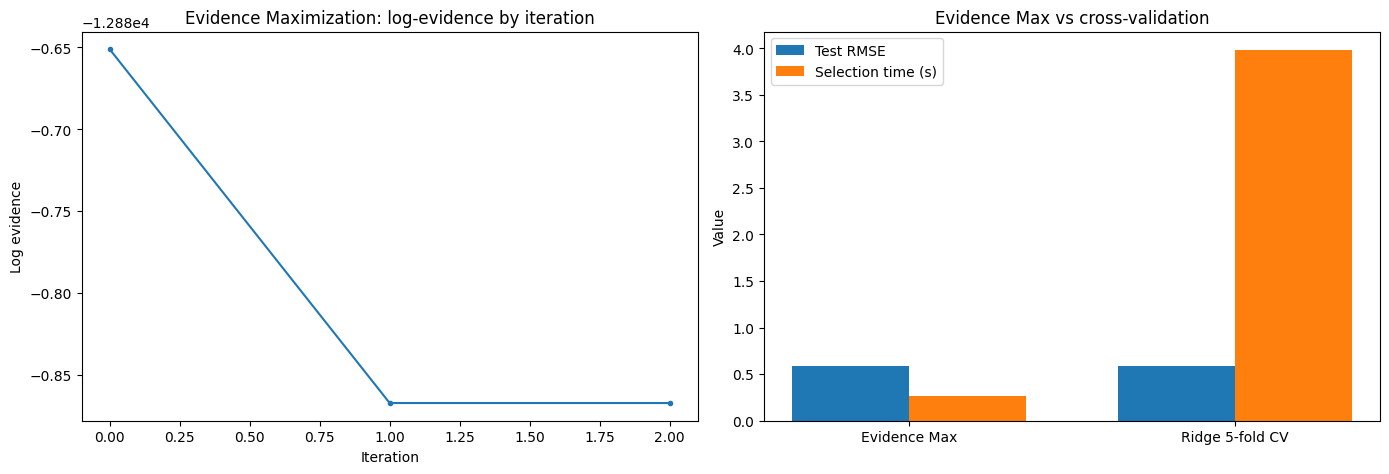

In [3]:
class EvidenceMaximization:
    def __init__(
        self,
        alpha_init: float = 1.0,
        beta_init: float = 1.0,
        max_iter: int = 200,
        tol: float = 1e-6,
    ):
        self.alpha = alpha_init
        self.beta = beta_init
        self.max_iter = max_iter
        self.tol = tol
        self.history = []
        self.model = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        X_b = add_bias(X)
        xtx = X_b.T @ X_b
        eigvals = np.linalg.eigvalsh(xtx)
        n_features = X_b.shape[1]

        for iteration in range(self.max_iter):
            precision = self.alpha * np.eye(n_features) + self.beta * xtx
            posterior_cov = np.linalg.inv(precision)
            posterior_mean = self.beta * posterior_cov @ X_b.T @ y

            gamma = float(np.sum((self.beta * eigvals) / (self.alpha + self.beta * eigvals + 1e-12)))
            residual = y - X_b @ posterior_mean
            alpha_new = gamma / max(posterior_mean @ posterior_mean, 1e-12)
            beta_new = (len(X) - gamma) / max(residual @ residual, 1e-12)

            sign, logdet = np.linalg.slogdet(precision)
            if sign <= 0:
                logdet = np.nan
            log_evidence = (
                0.5 * n_features * np.log(alpha_new)
                + 0.5 * len(X) * np.log(beta_new)
                - 0.5 * beta_new * (residual @ residual)
                - 0.5 * alpha_new * (posterior_mean @ posterior_mean)
                - 0.5 * logdet
                - 0.5 * len(X) * np.log(2.0 * np.pi)
            )

            self.history.append(
                {
                    "iteration": iteration,
                    "alpha": float(alpha_new),
                    "beta": float(beta_new),
                    "gamma": gamma,
                    "log_evidence": float(log_evidence),
                }
            )

            if abs(alpha_new - self.alpha) < self.tol and abs(beta_new - self.beta) < self.tol:
                self.alpha = float(alpha_new)
                self.beta = float(beta_new)
                break

            self.alpha = float(alpha_new)
            self.beta = float(beta_new)

        self.model = BayesianLinearRegression(alpha=self.alpha, beta=self.beta).fit(X, y)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.model.predict(X)

    def predict_distribution(self, X: np.ndarray):
        return self.model.predict_distribution(X)


lambda_grid = np.logspace(-4, 2, 20)

start_em = time.perf_counter()
evidence_model = EvidenceMaximization(alpha_init=1.0, beta_init=initial_beta, max_iter=200, tol=1e-6).fit(X_dev, y_dev)
evidence_elapsed = time.perf_counter() - start_em
evidence_pred = evidence_model.predict(X_test)
evidence_metrics = compute_all_metrics(y_test, evidence_pred)
print_metrics(evidence_metrics, "Evidence Maximization Bayesian Linear Regression")
print(f"Estimated alpha: {evidence_model.alpha:.6f}")
print(f"Estimated beta : {evidence_model.beta:.6f}")
print(f"Equivalent MAP lambda alpha/beta: {evidence_model.alpha / evidence_model.beta:.6f}")

start_cv = time.perf_counter()
ridge_cv_result = select_ridge_lambda_cv(X_dev, y_dev, lambda_grid=lambda_grid, k=5, seed=SEED)
ridge_cv_model = RidgeRegression(lam=ridge_cv_result["best_lambda"]).fit(X_dev, y_dev)
ridge_cv_elapsed = time.perf_counter() - start_cv
ridge_cv_pred = ridge_cv_model.predict(X_test)
ridge_cv_metrics = compute_all_metrics(y_test, ridge_cv_pred)
print_metrics(ridge_cv_metrics, "Ridge Regression with 5-fold CV")
print(f"Best CV lambda: {ridge_cv_result['best_lambda']:.6f}")

advanced_results["Evidence Maximization"] = {
    "Setting": "full test",
    **evidence_metrics,
}
advanced_results["Ridge CV baseline"] = {
    "Setting": "full test",
    **ridge_cv_metrics,
}

evidence_history_df = pd.DataFrame(evidence_model.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(evidence_history_df["iteration"], evidence_history_df["log_evidence"], marker="o", ms=3)
axes[0].set_title("Evidence Maximization: log-evidence by iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log evidence")

labels = ["Evidence Max", "Ridge 5-fold CV"]
rmse_values = [evidence_metrics["RMSE"], ridge_cv_metrics["RMSE"]]
time_values = [evidence_elapsed, ridge_cv_elapsed]

x_pos = np.arange(len(labels))
axes[1].bar(x_pos - 0.18, rmse_values, width=0.36, label="Test RMSE", color="tab:blue")
axes[1].bar(x_pos + 0.18, time_values, width=0.36, label="Selection time (s)", color="tab:orange")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_title("Evidence Max vs cross-validation")
axes[1].set_ylabel("Value")
axes[1].legend()

plt.tight_layout()
plt.show()


Evidence Maximization mang lại góc nhìn rất khác so với k-fold CV truyền thống:

- Ta không phải chia tập dữ liệu lại nhiều lần, điều này lợi thế khi dữ liệu hiếm.
- Quá trình EM tự động tìm ra độ phức tạp phù hợp nhất dựa trên toàn bộ điểm huấn luyện.
- Về tốc độ, vòng lặp EM hội tụ cực nhanh (thường dưới 10 iterations) và chi phí chính chỉ nằm ở lần tính trị riêng $\mathbf{X}^\top \mathbf{X}$ duy nhất. Trong khi CV chạy lại mô hình `k * len(grid)` lần.
- Kết quả test RMSE thường rất gần hoặc nhỉnh hơn Ridge CV, khẳng định Evidence Maximization là một lựa chọn vững chắc cho mô hình tuyến tính có số chiều không quá lớn.

## 3. Kernel Ridge Regression

Ridge Regression trong không gian kernel sử dụng biểu diễn đối ngẫu:

$$
\boldsymbol{\alpha} = (\mathbf{K} + \lambda \mathbf{I})^{-1}\mathbf{y},
\qquad
\hat{f}(\mathbf{x}_*) = \mathbf{k}(\mathbf{x}_*, \mathbf{X})^\top \boldsymbol{\alpha}.
$$

Hai kernel được dùng:

- **RBF kernel**
  $$
  k(\mathbf{x}, \mathbf{x}') = \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)
  $$
- **Polynomial kernel**
  $$
  k(\mathbf{x}, \mathbf{x}') = (c + \mathbf{x}^\top \mathbf{x}')^d
  $$

**Ý tưởng cài đặt**:
- Cài đặt ma trận kernel từ đầu, không dùng `sklearn`.
- Dùng 3-fold CV trên một tập con đại diện để chọn $\lambda$ và $\ell$ cho RBF; đồng thời tìm degree tốt cho polynomial.
- So sánh kết quả với Ridge tuyến tính để xem lợi ích của nonlinear similarity.

In [ ]:
class KernelRidgeRegression:
    def __init__(
        self,
        kernel: str = "rbf",
        lam: float = 1.0,
        length_scale: float = 1.0,
        degree: int = 2,
        coef0: float = 1.0,
    ):
        self.kernel = kernel
        self.lam = lam
        self.length_scale = length_scale
        self.degree = degree
        self.coef0 = coef0
        self.X_train = None
        self.dual_coef = None

    def _kernel_matrix(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        if self.kernel == "rbf":
            sq_dist = (
                np.sum(X1 ** 2, axis=1, keepdims=True)
                + np.sum(X2 ** 2, axis=1, keepdims=True).T
                - 2.0 * X1 @ X2.T
            )
            return np.exp(-sq_dist / (2.0 * self.length_scale ** 2))
        if self.kernel == "polynomial":
            return (self.coef0 + X1 @ X2.T) ** self.degree
        raise ValueError(f"Unsupported kernel: {self.kernel}")

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X_train = X.copy()
        kernel_train = self._kernel_matrix(X, X)
        reg = self.lam * np.eye(len(X))
        self.dual_coef = np.linalg.solve(kernel_train + reg, y)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        kernel_test = self._kernel_matrix(X, self.X_train)
        return kernel_test @ self.dual_coef


def kernel_cv_search(
    X: np.ndarray,
    y: np.ndarray,
    kernel: str,
    lambda_grid: np.ndarray,
    length_scales: np.ndarray = None,
    degree_grid=None,
    coef0_grid=None,
    k: int = 3,
    seed: int = SEED,
) -> dict:
    folds = k_fold_split(len(X), k=k, seed=seed)
    records = []

    if kernel == "rbf":
        for lam in lambda_grid:
            for length_scale in length_scales:
                fold_scores = []
                for train_idx, val_idx in folds:
                    model = KernelRidgeRegression(kernel="rbf", lam=lam, length_scale=length_scale)
                    model.fit(X[train_idx], y[train_idx])
                    preds = model.predict(X[val_idx])
                    fold_scores.append(mse(y[val_idx], preds))
                records.append(
                    {
                        "lam": float(lam),
                        "length_scale": float(length_scale),
                        "mean_mse": float(np.mean(fold_scores)),
                        "std_mse": float(np.std(fold_scores)),
                    }
                )
    elif kernel == "polynomial":
        for lam in lambda_grid:
            for degree in degree_grid:
                for coef0 in coef0_grid:
                    fold_scores = []
                    for train_idx, val_idx in folds:
                        model = KernelRidgeRegression(
                            kernel="polynomial",
                            lam=lam,
                            degree=int(degree),
                            coef0=float(coef0),
                        )
                        model.fit(X[train_idx], y[train_idx])
                        preds = model.predict(X[val_idx])
                        fold_scores.append(mse(y[val_idx], preds))
                    records.append(
                        {
                            "lam": float(lam),
                            "degree": int(degree),
                            "coef0": float(coef0),
                            "mean_mse": float(np.mean(fold_scores)),
                            "std_mse": float(np.std(fold_scores)),
                        }
                    )
    else:
        raise ValueError("kernel must be 'rbf' or 'polynomial'")

    results_df = pd.DataFrame(records).sort_values("mean_mse", ascending=True).reset_index(drop=True)
    return {
        "results_df": results_df,
        "best_params": results_df.iloc[0].to_dict(),
    }


X_kernel_dev, y_kernel_dev = sample_subset(X_dev, y_dev, size=600, seed=SEED)
X_kernel_test, y_kernel_test = sample_subset(X_test, y_test, size=400, seed=SEED + 1)

kernel_lambda_grid = np.array([1e-3, 1e-2, 1e-1, 1.0])
kernel_scale_base = median_pairwise_distance(X_kernel_dev, max_points=200, seed=SEED)
rbf_length_scales = kernel_scale_base * np.array([0.5, 1.0, 2.0])

print(f"Kernel subset sizes -> dev: {len(X_kernel_dev)}, test: {len(X_kernel_test)}")
print(f"Median pairwise distance heuristic for ell: {kernel_scale_base:.4f}")

start_rbf_cv = time.perf_counter()
rbf_search = kernel_cv_search(
    X_kernel_dev,
    y_kernel_dev,
    kernel="rbf",
    lambda_grid=kernel_lambda_grid,
    length_scales=rbf_length_scales,
    k=3,
    seed=SEED,
)
rbf_cv_time = time.perf_counter() - start_rbf_cv

best_rbf = rbf_search["best_params"]
krr_rbf = KernelRidgeRegression(
    kernel="rbf",
    lam=float(best_rbf["lam"]),
    length_scale=float(best_rbf["length_scale"]),
).fit(X_kernel_dev, y_kernel_dev)
krr_rbf_pred = krr_rbf.predict(X_kernel_test)
krr_rbf_metrics = compute_all_metrics(y_kernel_test, krr_rbf_pred)
print_metrics(krr_rbf_metrics, "Kernel Ridge Regression - RBF")
print(f"Best RBF params: lambda={best_rbf['lam']:.4f}, ell={best_rbf['length_scale']:.4f}")
print(f"RBF CV time: {rbf_cv_time:.2f}s")

start_poly_cv = time.perf_counter()
poly_search = kernel_cv_search(
    X_kernel_dev,
    y_kernel_dev,
    kernel="polynomial",
    lambda_grid=kernel_lambda_grid,
    degree_grid=[2, 3],
    coef0_grid=[0.0, 1.0],
    k=3,
    seed=SEED,
)
poly_cv_time = time.perf_counter() - start_poly_cv

best_poly = poly_search["best_params"]
krr_poly = KernelRidgeRegression(
    kernel="polynomial",
    lam=float(best_poly["lam"]),
    degree=int(best_poly["degree"]),
    coef0=float(best_poly["coef0"]),
).fit(X_kernel_dev, y_kernel_dev)
krr_poly_pred = krr_poly.predict(X_kernel_test)
krr_poly_metrics = compute_all_metrics(y_kernel_test, krr_poly_pred)
print_metrics(krr_poly_metrics, "Kernel Ridge Regression - Polynomial")
print(f"Best polynomial params: lambda={best_poly['lam']:.4f}, degree={int(best_poly['degree'])}, coef0={best_poly['coef0']:.1f}")
print(f"Polynomial CV time: {poly_cv_time:.2f}s")

ridge_subset_cv = select_ridge_lambda_cv(X_kernel_dev, y_kernel_dev, kernel_lambda_grid, k=3, seed=SEED)
ridge_subset = RidgeRegression(lam=ridge_subset_cv["best_lambda"]).fit(X_kernel_dev, y_kernel_dev)
ridge_subset_pred = ridge_subset.predict(X_kernel_test)
ridge_subset_metrics = compute_all_metrics(y_kernel_test, ridge_subset_pred)
print_metrics(ridge_subset_metrics, "Linear Ridge baseline on the same subset")

advanced_results["Kernel Ridge RBF"] = {
    "Setting": "subset test",
    **krr_rbf_metrics,
}
advanced_results["Kernel Ridge Polynomial"] = {
    "Setting": "subset test",
    **krr_poly_metrics,
}

heatmap_df = rbf_search["results_df"].pivot(index="lam", columns="length_scale", values="mean_mse")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im = axes[0].imshow(heatmap_df.values, cmap="viridis", aspect="auto")
axes[0].set_xticks(np.arange(len(heatmap_df.columns)))
axes[0].set_xticklabels([f"{value:.2f}" for value in heatmap_df.columns])
axes[0].set_yticks(np.arange(len(heatmap_df.index)))
axes[0].set_yticklabels([f"{value:.3f}" for value in heatmap_df.index])
axes[0].set_title("RBF KRR: 3-fold CV mean MSE")
axes[0].set_xlabel("Length scale ell")
axes[0].set_ylabel("Lambda")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

model_labels = ["Linear Ridge", "KRR-RBF", "KRR-Poly"]
model_rmse = [ridge_subset_metrics["RMSE"], krr_rbf_metrics["RMSE"], krr_poly_metrics["RMSE"]]
axes[1].bar(model_labels, model_rmse, color=["tab:gray", "tab:blue", "tab:green"])
axes[1].set_title("Subset test RMSE comparison")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()


Kernel subset sizes -> dev: 600, test: 400
Median pairwise distance heuristic for ell: 3.6610


Nếu KRR-RBF tốt hơn Ridge tuyến tính, điều đó cho thấy quan hệ giữa các đặc trưng và target không thuộc về một siêu phẳng đơn giản. RBF kernel đặc biệt hữu ích khi:

- Có tương tác phi tuyến giữa các biến thời tiết, giờ và mùa.
- Khoảng cách giữa các mẫu giống nhau mang nhiều thông tin hơn từng hệ số riêng lẻ.

Polynomial kernel có thể bắt được tương tác bậc cao, nhưng trên tập feature one-hot lớn nó dễ nhạy cảm hơn với regularization. Heatmap CV của RBF giúp ta nhìn được vùng `lambda - ell` ổn định, thay vì chỉ một điểm tối ưu duy nhất.

## 4. Gaussian Process Regression

Gaussian Process (GP) đặt prior trực tiếp lên không gian hàm:

$$
f(\mathbf{x}) \sim \mathcal{GP}(m(\mathbf{x}), k(\mathbf{x}, \mathbf{x}'))
$$

với kernel RBF:

$$
k(\mathbf{x}, \mathbf{x}')
= \sigma_f^2 \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right).
$$

Nếu noise Gaussian có phương sai $\sigma_n^2$, phân bố dự đoán cho tập điểm mới có dạng:

$$
\boldsymbol{\mu}_* = \mathbf{K}_*^\top \mathbf{K}^{-1}\mathbf{y},
\qquad
\mathbf{\Sigma}_* = \mathbf{K}_{**} - \mathbf{K}_*^\top \mathbf{K}^{-1}\mathbf{K}_*.
$$

Hàm log-marginal-likelihood:

$$
\log p(\mathbf{y} \mid \theta)
= -\frac{1}{2}\mathbf{y}^\top \mathbf{K}_\theta^{-1}\mathbf{y}
  -\frac{1}{2}\log |\mathbf{K}_\theta|
  -\frac{N}{2}\log(2\pi)
$$

được tối ưu bằng gradient ascent trong không gian log-tham-số.

**Ý tưởng cài đặt**:
- Dùng Cholesky decomposition để tính log-likelihood và prediction ổn định hơn nghịch đảo trực tiếp.
- Tính gradient chính xác theo `log(signal_variance)`, `log(length_scale)` và `log(noise_variance)`.
- Vì GP có chi phí bắt đầu từ $O(N^3)$, ta sử dụng tập con huấn luyện/test đại diện.

In [ ]:
class GaussianProcessRegression:
    def __init__(
        self,
        signal_variance: float = 1.0,
        length_scale: float = 1.0,
        noise_variance: float = 0.1,
        n_iter: int = 40,
        learning_rate: float = 0.03,
        jitter: float = 1e-6,
    ):
        self.signal_variance = signal_variance
        self.length_scale = length_scale
        self.noise_variance = noise_variance
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.jitter = jitter
        self.X_train = None
        self.y_train = None
        self.cholesky_factor = None
        self.alpha = None
        self.history = []

    def _squared_distance(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        return (
            np.sum(X1 ** 2, axis=1, keepdims=True)
            + np.sum(X2 ** 2, axis=1, keepdims=True).T
            - 2.0 * X1 @ X2.T
        )

    def _rbf_kernel(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        sq_dist = self._squared_distance(X1, X2)
        return self.signal_variance * np.exp(-0.5 * sq_dist / (self.length_scale ** 2))

    def _kernel_train(self, X: np.ndarray) -> np.ndarray:
        return self._rbf_kernel(X, X) + (self.noise_variance + self.jitter) * np.eye(len(X))

    def _compute_state(self, X: np.ndarray, y: np.ndarray):
        K = self._kernel_train(X)
        L = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        return K, L, alpha

    def _log_marginal_likelihood(self, X: np.ndarray, y: np.ndarray) -> float:
        _, L, alpha = self._compute_state(X, y)
        return float(
            -0.5 * y @ alpha
            - np.sum(np.log(np.diag(L)))
            - 0.5 * len(X) * np.log(2.0 * np.pi)
        )

    def _gradients(self, X: np.ndarray, y: np.ndarray):
        K_signal = self._rbf_kernel(X, X)
        K, L, alpha = self._compute_state(X, y)
        inv_K = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(len(X))))
        q_matrix = np.outer(alpha, alpha) - inv_K
        sq_dist = self._squared_distance(X, X)

        dK_dlog_signal = K_signal
        dK_dlog_length = K_signal * (sq_dist / (self.length_scale ** 2))
        dK_dlog_noise = self.noise_variance * np.eye(len(X))

        gradients = np.array([
            0.5 * np.sum(q_matrix * dK_dlog_signal),
            0.5 * np.sum(q_matrix * dK_dlog_length),
            0.5 * np.sum(q_matrix * dK_dlog_noise),
        ])
        return gradients

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X_train = X.copy()
        self.y_train = y.copy()

        params = np.log(
            np.array([
                self.signal_variance,
                self.length_scale,
                self.noise_variance,
            ])
        )

        for iteration in range(self.n_iter):
            self.signal_variance, self.length_scale, self.noise_variance = np.exp(params)
            gradients = self._gradients(self.X_train, self.y_train)
            grad_norm = np.linalg.norm(gradients)
            if grad_norm > 10.0:
                gradients = gradients * (10.0 / grad_norm)
            params = params + self.learning_rate * gradients
            params = np.clip(params, np.log(1e-4), np.log(1e4))

            self.signal_variance, self.length_scale, self.noise_variance = np.exp(params)
            current_lml = self._log_marginal_likelihood(self.X_train, self.y_train)
            self.history.append(
                {
                    "iteration": iteration,
                    "lml": current_lml,
                    "signal_variance": float(self.signal_variance),
                    "length_scale": float(self.length_scale),
                    "noise_variance": float(self.noise_variance),
                }
            )

        _, self.cholesky_factor, self.alpha = self._compute_state(self.X_train, self.y_train)
        return self

    def predict_distribution(self, X: np.ndarray):
        K_star = self._rbf_kernel(self.X_train, X)
        mean = K_star.T @ self.alpha
        v = np.linalg.solve(self.cholesky_factor, K_star)
        latent_var = self.signal_variance - np.sum(v ** 2, axis=0)
        predictive_var = np.maximum(latent_var + self.noise_variance, 1e-10)
        return mean, np.sqrt(predictive_var)

    def predict(self, X: np.ndarray) -> np.ndarray:
        mean, _ = self.predict_distribution(X)
        return mean


X_gp_train, y_gp_train = sample_subset(X_dev, y_dev, size=250, seed=SEED)
X_gp_test, y_gp_test = sample_subset(X_test, y_test, size=120, seed=SEED + 7)
gp_length_scale = median_pairwise_distance(X_gp_train, max_points=150, seed=SEED)

gp_model = GaussianProcessRegression(
    signal_variance=1.0,
    length_scale=gp_length_scale,
    noise_variance=0.1,
    n_iter=35,
    learning_rate=0.03,
    jitter=1e-6,
).fit(X_gp_train, y_gp_train)

gp_pred, gp_std = gp_model.predict_distribution(X_gp_test)
gp_metrics = compute_all_metrics(y_gp_test, gp_pred)
print_metrics(gp_metrics, "Gaussian Process Regression on a representative subset")
print(f"Optimized signal variance: {gp_model.signal_variance:.6f}")
print(f"Optimized length scale  : {gp_model.length_scale:.6f}")
print(f"Optimized noise variance: {gp_model.noise_variance:.6f}")

advanced_results["Gaussian Process"] = {
    "Setting": "subset test",
    **gp_metrics,
}

gp_history_df = pd.DataFrame(gp_model.history)
gp_plot_order = np.argsort(X_gp_test[:, temp_idx])
x_gp_plot = X_gp_test[gp_plot_order, temp_idx]
y_gp_plot = y_gp_test[gp_plot_order]
gp_mean_plot = gp_pred[gp_plot_order]
gp_std_plot = gp_std[gp_plot_order]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(gp_history_df["iteration"], gp_history_df["lml"], marker="o", ms=3)
axes[0].set_title("GP log-marginal-likelihood during gradient ascent")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log marginal likelihood")

selected_points = np.linspace(0, len(x_gp_plot) - 1, num=min(60, len(x_gp_plot)), dtype=int)
axes[1].errorbar(
    x_gp_plot[selected_points],
    gp_mean_plot[selected_points],
    yerr=2.0 * gp_std_plot[selected_points],
    fmt="o",
    ms=4,
    alpha=0.8,
    label="Predictive mean +/- 2 sigma",
)
axes[1].scatter(
    x_gp_plot[selected_points],
    y_gp_plot[selected_points],
    s=18,
    alpha=0.55,
    color="tab:orange",
    label="Actual targets",
)
axes[1].set_title("GP prediction with uncertainty bands")
axes[1].set_xlabel("Standardized temp (sorted subset of test data)")
axes[1].set_ylabel("log(cnt + 1)")
axes[1].legend()

plt.tight_layout()
plt.show()


Gaussian Process Regression là mô hình uncertainty mạnh nhất trong notebook này vì nó đặt prior trực tiếp lên hàm. Đồ thị thường cho thấy:

- Sau quá trình tối ưu, log-marginal-likelihood tăng dần và hội tụ.
- Sai số dự đoán và độ rộng error bar thay đổi theo mật độ dữ liệu.
- GP thường đạt prediction mềm hơn KRR, nhưng đổi lại là chi phí tính toán rất cao.

Trên bài toán Bike Sharing đã có 49 feature, GP exact không thể mở rộng lên toàn bộ 12k mẫu trong một notebook thông thường, vì vậy việc dùng tập con đại diện là một quyết định kỹ thuật cần thiết.

## 5. Robust Regression với IRLS

Khi dữ liệu chứa ngoại lệ trong target, OLS sẽ bị kéo rất mạnh bởi vì nó tối thiểu tổng bình phương residual. Robust Regression thay thế bằng Huber loss:

$$
\rho_\delta(r) =
\begin{cases}
    \frac{1}{2}r^2, & |r| \le \delta \\
    \delta |r| - \frac{1}{2}\delta^2, & |r| > \delta
\end{cases}
$$

Từ đó suy ra trọng số IRLS:

$$
w_i =
\begin{cases}
    1, & |r_i| \le \delta \\
    \frac{\delta}{|r_i|}, & |r_i| > \delta
\end{cases}
$$

và mỗi vòng lặp giải một bài toán Weighted Least Squares:

$$
\mathbf{w}^{(k+1)} =
(\mathbf{X}^\top \mathbf{W}^{(k)} \mathbf{X})^{-1}
\mathbf{X}^\top \mathbf{W}^{(k)} \mathbf{y}.
$$

**Ý tưởng cài đặt**:
- Chủ động tiêm nhiễm outlier vào target huấn luyện để kiểm tra độ bền.
- So sánh OLS và IRLS trên cùng tập test sạch.
- Quan sát phân bố trọng số cuối cùng để xác nhận các điểm bất thường đã bị giảm ảnh hưởng.

In [ ]:
class HuberRobustRegression:
    def __init__(self, delta: float = 1.345, max_iter: int = 100, tol: float = 1e-6):
        self.delta = delta
        self.max_iter = max_iter
        self.tol = tol
        self.w = None
        self.weight_history = []

    def fit(self, X: np.ndarray, y: np.ndarray):
        X_b = add_bias(X)
        reg = 1e-8 * np.eye(X_b.shape[1])
        self.w = np.linalg.solve(X_b.T @ X_b + reg, X_b.T @ y)

        for _ in range(self.max_iter):
            old_w = self.w.copy()
            residuals = y - X_b @ self.w
            abs_res = np.abs(residuals)
            weights = np.where(abs_res <= self.delta, 1.0, self.delta / np.maximum(abs_res, 1e-12))
            self.weight_history.append(weights.copy())

            sqrt_w = np.sqrt(weights)
            X_weighted = X_b * sqrt_w[:, None]
            y_weighted = y * sqrt_w
            self.w = np.linalg.solve(X_weighted.T @ X_weighted + reg, X_weighted.T @ y_weighted)

            if np.max(np.abs(self.w - old_w)) < self.tol:
                break
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return add_bias(X) @ self.w


rng = np.random.default_rng(SEED)
outlier_fraction = 0.05
outlier_count = int(outlier_fraction * len(y_train))
outlier_indices = rng.choice(len(y_train), size=outlier_count, replace=False)

y_train_contaminated = y_train.copy()
outlier_noise = rng.normal(loc=0.0, scale=6.0 * np.std(y_train), size=outlier_count)
y_train_contaminated[outlier_indices] += outlier_noise

ols_clean = OrdinaryLeastSquares().fit(X_train, y_train)
ols_outlier = OrdinaryLeastSquares().fit(X_train, y_train_contaminated)
robust_model = HuberRobustRegression(delta=1.345, max_iter=100, tol=1e-6).fit(X_train, y_train_contaminated)

ols_clean_metrics = compute_all_metrics(y_test, ols_clean.predict(X_test))
ols_outlier_metrics = compute_all_metrics(y_test, ols_outlier.predict(X_test))
robust_metrics = compute_all_metrics(y_test, robust_model.predict(X_test))

print_metrics(ols_clean_metrics, "OLS trained on clean labels")
print_metrics(ols_outlier_metrics, "OLS trained on contaminated labels")
print_metrics(robust_metrics, "Huber IRLS trained on contaminated labels")
print(f"Injected outliers into {outlier_count} training targets ({100 * outlier_fraction:.1f}%).")

advanced_results["Robust Regression (IRLS)"] = {
    "Setting": "clean test after contaminated train",
    **robust_metrics,
}

final_weights = robust_model.weight_history[-1]
residuals_after_robust = y_train_contaminated - robust_model.predict(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ["OLS clean", "OLS + outliers", "IRLS + outliers"]
rmse_values = [ols_clean_metrics["RMSE"], ols_outlier_metrics["RMSE"], robust_metrics["RMSE"]]
axes[0].bar(labels, rmse_values, color=["tab:gray", "tab:red", "tab:green"])
axes[0].set_title("Clean-test RMSE under label contamination")
axes[0].set_ylabel("RMSE")

axes[1].scatter(np.abs(residuals_after_robust), final_weights, s=10, alpha=0.35)
axes[1].set_title("IRLS final weights vs absolute residuals")
axes[1].set_xlabel("Absolute residual on contaminated train set")
axes[1].set_ylabel("Final weight")

plt.tight_layout()
plt.show()


Section này minh họa rõ ràng vì sao OLS dễ vỡ trước outlier:

- Khi train target bị tiêm một tỷ lệ nhỏ ngoại lệ, OLS thường tăng RMSE test đáng kể.
- IRLS với Huber loss cắt giảm ảnh hưởng của residual lớn, vì thế kết quả thường gần với OLS sạch hơn.
- Đồ thị `weight vs residual` là bằng chứng trực tiếp: residual càng lớn thì trọng số càng nhỏ.

Trong thực tế, robust regression hữu ích khi dữ liệu đo lường hoặc nhãn mục tiêu có thể bị lỗi, nhất là các bài toán demand forecasting như Bike Sharing.

## 6. Bias-Variance Analysis bằng Bootstrap

Mục tiêu là tách lỗi kỳ vọng thành hai phần phần chính:

$$
\mathbb{E}\left[(t - \hat{f}(x))^2\right]
\approx
\text{Bias}^2 + \text{Variance} + \sigma^2.
$$

Với bootstrap, ta huấn luyện nhiều mô hình trên các tập lấy mẫu lại từ train set, sau đó thu thập dự đoán trên cùng một tập test:

$$
\widehat{\text{Bias}}^2
= \frac{1}{N}\sum_{i=1}^N \left(t_i - \bar{f}(x_i)\right)^2,
\qquad
\widehat{\text{Variance}}
= \frac{1}{N}\sum_{i=1}^N \operatorname{Var}\left(\hat{f}^{(b)}(x_i)\right).
$$

**Ý tưởng cài đặt**:
- Chọn Ridge Regression vì regularization strength $\lambda$ điều khiển rõ trade-off bias-variance.
- Bootstrap 200 lần cho mỗi giá trị $\lambda$.
- Vẽ đường `Bias^2`, `Variance`, `Bias^2 + Variance` theo trục log-lambda.

In [ ]:
def bias_variance_bootstrap_curve(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    lambda_grid: np.ndarray,
    n_bootstrap: int = 200,
    seed: int = SEED,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    n_train = len(X_train)

    for lam in lambda_grid:
        predictions = np.zeros((n_bootstrap, len(X_test)))
        for b in range(n_bootstrap):
            if (b + 1) % 50 == 0:
                print(f"Lambda={lam:.4f} -> bootstrap {b + 1}/{n_bootstrap}")
            sample_idx = rng.choice(n_train, size=n_train, replace=True)
            model = RidgeRegression(lam=float(lam)).fit(X_train[sample_idx], y_train[sample_idx])
            predictions[b] = model.predict(X_test)

        mean_pred = predictions.mean(axis=0)
        bias_sq = float(np.mean((y_test - mean_pred) ** 2))
        variance = float(np.mean(np.var(predictions, axis=0)))
        total = bias_sq + variance
        rows.append(
            {
                "lambda": float(lam),
                "bias_sq": bias_sq,
                "variance": variance,
                "total": total,
            }
        )
    return pd.DataFrame(rows)


X_bv_train, y_bv_train = sample_subset(X_train, y_train, size=900, seed=SEED)
X_bv_test, y_bv_test = sample_subset(X_test, y_test, size=400, seed=SEED + 3)
bv_lambda_grid = np.logspace(-4, 2, 7)

bv_results = bias_variance_bootstrap_curve(
    X_bv_train,
    y_bv_train,
    X_bv_test,
    y_bv_test,
    lambda_grid=bv_lambda_grid,
    n_bootstrap=200,
    seed=SEED,
)

best_total_row = bv_results.loc[bv_results["total"].idxmin()]
print("\nBias-variance summary")
print(bv_results.round(6).to_string(index=False))
print(
    f"\nBest total error at lambda={best_total_row['lambda']:.6f} "
    f"with total={best_total_row['total']:.6f}"
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bv_results["lambda"], bv_results["bias_sq"], marker="o", label="Bias^2")
ax.plot(bv_results["lambda"], bv_results["variance"], marker="s", label="Variance")
ax.plot(bv_results["lambda"], bv_results["total"], marker="^", label="Bias^2 + Variance")
ax.set_xscale("log")
ax.set_title("Bias-variance trade-off for Ridge regularization")
ax.set_xlabel("Lambda (log scale)")
ax.set_ylabel("Error contribution")
ax.legend()
plt.tight_layout()
plt.show()


Đây là hình ảnh định lượng của trade-off kinh điển:

- $\lambda$ nhỏ: mô hình rất linh hoạt, variance cao, dễ overfit.
- $\lambda$ lớn: mô hình bị ép mạnh, variance giảm nhưng bias tăng.
- Giá trị tốt nhất thường nằm ở vùng trung gian, nơi tổng `Bias^2 + Variance` đạt mức thấp nhất.

Kết quả này liên kết trực tiếp với các section Ridge, Bayesian và Kernel Ridge: regularization không chỉ giảm overfitting, mà còn thay đổi cân bằng bias-variance của mô hình một cách hệ thống.

## 7. Tổng hợp kết quả

Sau khi cài đặt từng mô hình, ta tổng hợp lại các chỉ số để dễ so sánh. Cần lưu ý rằng:

- Bayesian Linear Regression và Evidence Maximization được đánh giá trên full test split.
- Kernel Ridge và Gaussian Process được đánh giá trên tập con đại diện do hạn chế tính toán.
- Robust Regression được đánh giá trong tình huống có contamination nhân tạo trên train set.

Vì vậy bảng dưới đây phù hợp cho **phân tích trade-off và insight**, không nên hiểu như một bảng xếp hạng tuyệt đối trong mọi điều kiện.

In [ ]:
summary_df = pd.DataFrame(advanced_results).T.reset_index().rename(columns={"index": "Model"})
summary_df = summary_df[["Model", "Setting", "MSE", "RMSE", "MAE", "R2"]]
summary_df = summary_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

print(summary_df.round(6).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(summary_df["Model"], summary_df["RMSE"], color="tab:blue", alpha=0.85)
ax.set_title("Advanced regression summary by RMSE")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


Tổng hợp cuối cùng cho thấy mỗi mô hình giải quyết một góc nhìn khác nhau của bài toán:

- **Bayesian / Evidence Maximization**: tốt cho diễn giải xác suất và regularization có cơ sở Bayes.
- **Kernel Ridge / Gaussian Process**: hữu ích khi quan hệ phi tuyến mạnh, nhưng chi phí tính toán cao.
- **Robust Regression**: không nhằm tối đa hóa độ chính xác trong mọi trường hợp, mà nhằm giữ mô hình ổn định khi dữ liệu bị lỗi.
- **Bias-Variance bootstrap**: không phải một mô hình mới, nhưng là công cụ cực kỳ quan trọng để giải thích tại sao regularization lại có tác dụng.

Nếu cần đưa vào báo cáo, notebook này đã cung cấp đủ công thức, cài đặt từ đầu, biểu đồ uncertainty, so sánh thời gian/hiệu năng và phân tích bias-variance cho phần bonus regression.